<a href="https://colab.research.google.com/github/xseeker0/neural-scratchpad/blob/main/practice_4_2_vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!python --version

Python 3.12.12


# ViT
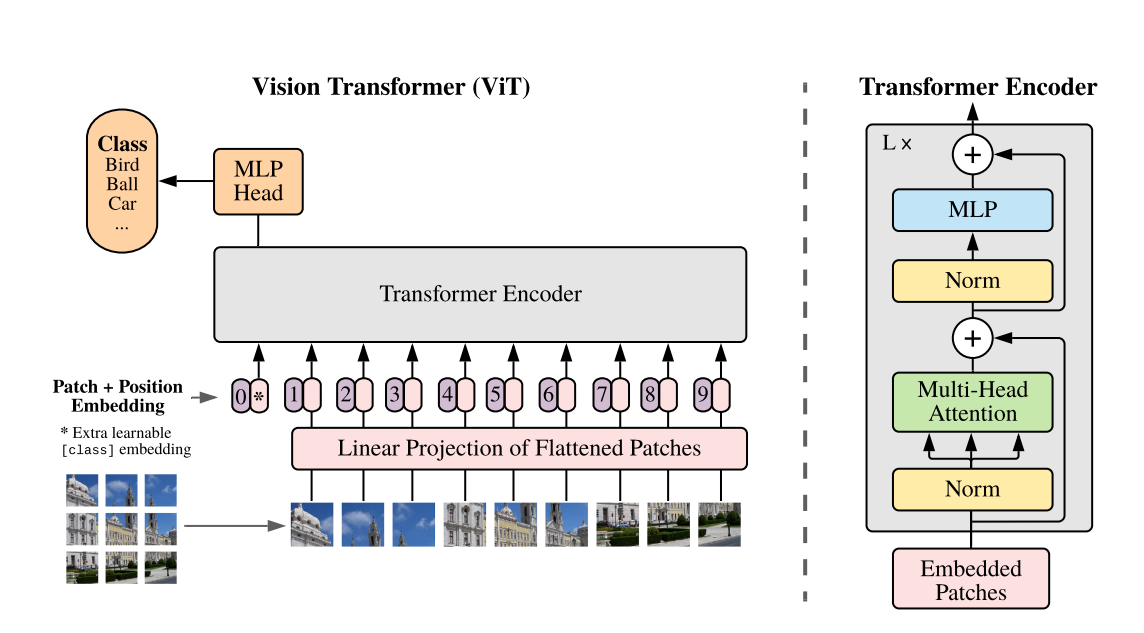

## Patch Embedding
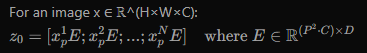

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import math

class PatchEmbedding(nn.Module):
    """
    Project 2D image into 1D sequence of learnable patch embeddings.
    Mathematically equivalent to manual patching + linear projection.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2

        # kernel_size=patch_size and stride=patch_size ensures non-overlapping patches
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # Input: (B, C, H, W)
        x = self.proj(x)  # Output: (B, embed_dim, H/P, W/P) -> (B, 768, 14, 14)
        x = x.flatten(2)  # Output: (B, 768, 196)
        x = x.transpose(1, 2)  # Output: (B, 196, 768) - Ready for Transformer
        return x

## Stochastic Depth

In [3]:
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x

        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor

## Multi-Head Self-Attention

In [4]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, attn_drop=0.0, proj_drop=0.0):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Single linear layer for QKV
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)

        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

        self.attn_drop = attn_drop

    def forward(self, x):
        B, N, C = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        # Use PyTorch optimized attention
        x = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.attn_drop if self.training else 0.0,
            is_causal=False
        )

        # Merge heads
        x = x.transpose(1, 2).reshape(B, N, C)

        x = self.proj(x)
        x = self.proj_drop(x)

        return x

## MLP

In [5]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, dropout=0.):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

## Transformer Block

In [6]:
class Block(nn.Module):
    def __init__(
        self,
        embed_dim=768,
        num_heads=12,
        mlp_ratio=4.0,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_drop, drop)
        self.drop_path = DropPath(drop_path)

        self.norm2 = nn.LayerNorm(embed_dim)
        # Correctly pass hidden_features and out_features as integers
        self.mlp = MLP(in_features=embed_dim, hidden_features=int(embed_dim * mlp_ratio), out_features=embed_dim, dropout=drop)

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

## ViT Architecture

In [7]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,              # Input image resolution
        patch_size=16,             # Patch resolution
        in_channels=3,             # Number of input channels
        num_classes=1000,          # Number of output classes
        embed_dim=768,             # Transformer embedding dimension
        depth=12,                  # Number of Transformer blocks
        num_heads=12,              # Number of attention heads
        mlp_ratio=4.0,             # Expansion ratio inside MLP
        drop_rate=0.1,             # Dropout after embeddings and inside MLP
        attn_drop_rate=0.0,        # Dropout inside attention map
        drop_path_rate=0.1,        # Stochastic depth rate
        representation_size=None   # Optional pre-logits layer (used in original paper)
    ):
        super().__init__()

        # Patch embedding layer
        # Converts image into patch tokens
        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )

        num_patches = self.patch_embed.n_patches

        # Learnable classification token (prepended to patch sequence)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Learnable positional embeddings (for CLS + patches)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Dropout applied after adding positional embeddings
        self.pos_drop = nn.Dropout(p=drop_rate)

        # Stochastic depth decay rule (linearly increasing)
        dpr = torch.linspace(0, drop_path_rate, depth)

        # Transformer encoder blocks
        self.blocks = nn.ModuleList([
            Block(
                embed_dim,
                num_heads,
                mlp_ratio,
                drop_rate,
                attn_drop_rate,
                dpr[i].item()
            )
            for i in range(depth)
        ])

        # Final normalization layer (Pre-LN architecture)
        self.norm = nn.LayerNorm(embed_dim)

        # Optional representation layer before classifier
        # Used in original ViT paper for large-scale pretraining
        if representation_size:
            self.pre_logits = nn.Sequential(
                nn.Linear(embed_dim, representation_size),
                nn.Tanh()
            )
            self.head = nn.Linear(representation_size, num_classes)
        else:
            self.pre_logits = nn.Identity()
            self.head = nn.Linear(embed_dim, num_classes)

        # Initialize all weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

        # Initialize learnable embeddings
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):

        B = x.shape[0]  # Batch size

        # Patch embedding
        # Shape: (B, num_patches, embed_dim)
        x = self.patch_embed(x)

        # Expand CLS token for batch
        cls_tokens = self.cls_token.expand(B, -1, -1)
        # Concatenate CLS token with patch tokens
        # Shape becomes (B, num_patches + 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)

        # Add positional embeddings
        x = x + self.pos_embed
        # Apply dropout after positional encoding
        x = self.pos_drop(x)

        # Pass through Transformer encoder blocks
        for blk in self.blocks:
            x = blk(x)
        # Final layer normalization
        x = self.norm(x)

        # Extract CLS token representation
        cls_output = x[:, 0]

        # pre-logits transformation
        x = self.pre_logits(cls_output)

        # Classification head
        x = self.head(x)

        return x

model = VisionTransformer()

print(model)
def count_parameters(model):
    # Trainable
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'-'*30}")
    print(f"Model Name: {model.__class__.__name__}")
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"{'-'*30}\n")

count_parameters(model)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (drop_path): DropPath()
      (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (pre_logits): Identity()
  (head): Linear(in_features=768

# Train with CIFAR100 dataset

## Load data

In [8]:
dataset = load_dataset("cifar100")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'fine_label', 'coarse_label'],
        num_rows: 10000
    })
})


In [9]:
def get_dataloader(dataset_split, batch_size=64, img_size=224, shuffle=False):
    """
    Applies ViT preprocessing.
    """

    # Stats for CIFAR-100
    mean, std = [0.5071, 0.4867, 0.4408], [0.2675, 0.2565, 0.2761]

    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

    def preprocess_fn(examples):
        pixel_values = [transform(image.convert("RGB")) for image in examples["img"]]
        fine_labels = examples["fine_label"]
        return {"pixel_values": pixel_values, "fine_label": fine_labels}

    dataset_split.set_transform(preprocess_fn)
    return DataLoader(dataset_split, batch_size=batch_size, shuffle=shuffle)


# Load dataloaders
train_loader = get_dataloader(dataset["train"], batch_size=128, shuffle=True)
test_loader = get_dataloader(dataset["test"], batch_size=128, shuffle=False)

## Training loop

In [10]:
from torch.cuda.amp import autocast, GradScaler

def train_one_epoch_amp(model, loader, optimizer, criterion, device):
    model.train()
    # Initialize the GradScaler
    scaler = GradScaler()

    total_loss, correct, total = 0, 0, 0
    loop = tqdm(loader, desc="Training (AMP)", leave=False)

    for batch in loop:
        inputs = batch["pixel_values"].to(device)
        labels = torch.tensor(batch["fine_label"]).to(device)

        optimizer.zero_grad()

        # 1. Runs the forward pass with autocasting
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # 2. Scales the loss and calls backward() to create scaled gradients
        scaler.scale(loss).backward()

        # 3. scaler.step() first unscales the gradients of the optimizer's assigned params.
        # If these gradients do not contain infs/NaNs, optimizer.step() is then called,
        # otherwise, optimizer.step() is skipped.
        scaler.step(optimizer)

        # 4. Updates the scale for next iteration
        scaler.update()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.2f}%")

    return total_loss / len(loader), 100. * correct / total



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer(img_size=224).to(device)
count_parameters(model)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print(f"Training ViT on CIFAR-100 ({device})...")
epoch = 5
for epoch in range(1, epoch+1):
    loss, acc = train_one_epoch_amp(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

/tmp/ipykernel_4174/109018668.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



------------------------------
Model Name: VisionTransformer
Total Parameters: 86,567,656
Trainable Parameters: 86,567,656
------------------------------

Training ViT on CIFAR-100 (cuda)...


Training (AMP):   0%|          | 0/391 [00:00<?, ?it/s]/tmp/ipykernel_4174/109018668.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["fine_label"]).to(device)
/tmp/ipykernel_4174/109018668.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Loss: 4.2617 | Accuracy: 5.18%


Epoch 2 | Loss: 4.0539 | Accuracy: 7.44%


Epoch 3 | Loss: 4.0656 | Accuracy: 7.33%


Epoch 4 | Loss: 4.2097 | Accuracy: 5.62%


Epoch 5 | Loss: 4.1733 | Accuracy: 6.16%


## Test

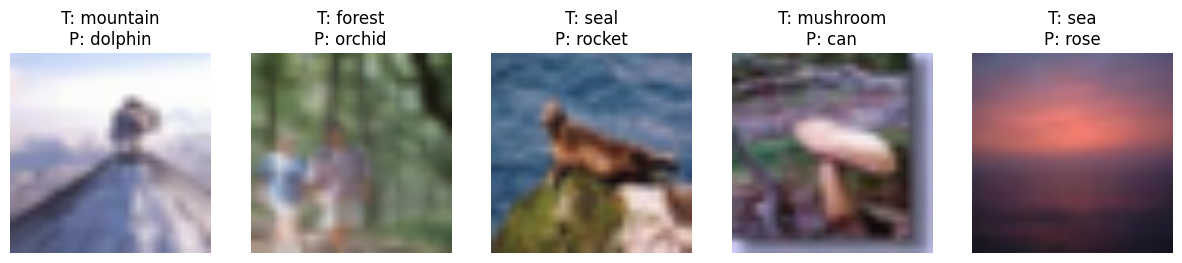

In [11]:
# Plotting sample predictions
def plot_results(model, loader, device, num_samples=5):
    model.eval()
    batch = next(iter(loader))
    inputs = batch["pixel_values"][:num_samples].to(device)
    labels = batch["fine_label"][:num_samples]

    # Get class names from metadata
    class_names = dataset['test'].features["fine_label"].names

    with torch.no_grad():
        preds = torch.argmax(model(inputs), dim=1)

    plt.figure(figsize=(15, 4))
    for i in range(num_samples):
        # Unnormalize image
        img = inputs[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array([0.2675, 0.2565, 0.2761]) + np.array([0.5071, 0.4867, 0.4408])

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title(f"T: {class_names[labels[i]]}\nP: {class_names[preds[i]]}")
        plt.axis('off')
    plt.show()

plot_results(model, test_loader, device)

In [12]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            labels = torch.tensor(batch["fine_label"]).to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

print(evaluate(model, test_loader, device))

/tmp/ipykernel_4174/308268406.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(batch["fine_label"]).to(device)


6.79


In [13]:
from google.colab import runtime
print("Shutting down now.")
runtime.unassign()

Shutting down now.


##